# Pairwise curvature correlation


## Config — the only cell you need to edit

In [ ]:

FILE_A = r"MY_PATH\clustering_ML\results\synthetic_data\ID_F\hyperedge\LP_OR_MMOT_curvature.txt"
FILE_B = r"MY_PATH\clustering_ML\results\synthetic_data\ID_F\hyperedge\OR_MMOT_curvature.txt"

DROP_NAN  = True   # drop a row if either file reports a missing/non-numeric value
MIN_GROUP = 3      # cardinality levels with fewer rows than this report NaN

## Setup

In [30]:

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

INDEX_KEY = re.compile(r"^\d+(,\d+)*$")


def read_curvature(path):
    """Parse '<key> : <value>' lines into a DataFrame(key, cardinality, value)."""
    rows = []
    for line in Path(path).read_text().splitlines():
        line = line.strip()
        if not line:
            continue
        key_raw, value_raw = line.rsplit(":", 1)
        key_raw = key_raw.strip()
        indexed = bool(INDEX_KEY.match(key_raw))
        try:
            value = float(value_raw)
        except ValueError:
            value = np.nan
        rows.append({
            "key": frozenset(int(i) for i in key_raw.split(",")) if indexed else key_raw,
            "cardinality": float(key_raw.count(",") + 1) if indexed else np.nan,
            "value": value,
        })
    return pd.DataFrame(rows)


def match_files(path_a, path_b):
    """Join two files on the index-list key, falling back to positional matching."""
    a, b = read_curvature(path_a), read_curvature(path_b)
    joinable = (
        a["cardinality"].notna().all() and b["cardinality"].notna().all()
        and not a["key"].duplicated().any() and not b["key"].duplicated().any()
    )
    if joinable:
        df = a.merge(b[["key", "value"]], on="key", suffixes=("_a", "_b"))
        print(f"matched {len(df)} rows on index keys ({len(a)} in A, {len(b)} in B)")
    else:
        if len(a) != len(b):
            raise ValueError(f"cannot match: {len(a)} rows vs {len(b)} rows, no usable keys")
        df = a.rename(columns={"value": "value_a"}).assign(value_b=b["value"].to_numpy())
        print(f"matched {len(df)} rows by position (no usable index keys)")
    return df


def corr(x, y, min_n=3):
    """Pearson r and Spearman rho, or (nan, nan) if undefined."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    if len(x) < min_n or np.ptp(x) == 0 or np.ptp(y) == 0:
        return np.nan, np.nan
    return float(stats.pearsonr(x, y).statistic), float(stats.spearmanr(x, y).statistic)

## The analysis

In [31]:

def analyse(path_a, path_b, drop_nan=True, min_group=3):
    """Correlate two curvature files: pooled, stratified by cardinality, plus scatters."""
    name_a, name_b = Path(path_a).stem, Path(path_b).stem
    df = match_files(path_a, path_b)

    if drop_nan:
        before = len(df)
        df = df.dropna(subset=["value_a", "value_b"]).reset_index(drop=True)
        if len(df) < before:
            print(f"dropped {before - len(df)} rows with a missing value")

    # --- pooled ---
    r, rho = corr(df["value_a"], df["value_b"])
    print(f"\nPOOLED   n={len(df)}   Pearson r={r:.4f}   Spearman rho={rho:.4f}")

    # --- stratified by cardinality ---
    strat = pd.DataFrame(columns=["n", "pearson_r", "spearman_rho"])
    has_card = df["cardinality"].notna().any()
    if has_card:
        strat = pd.DataFrame([
            {"cardinality": int(card), "n": len(g),
             "pearson_r": corr(g["value_a"], g["value_b"], min_group)[0],
             "spearman_rho": corr(g["value_a"], g["value_b"], min_group)[1]}
            for card, g in df.dropna(subset=["cardinality"]).groupby("cardinality")
        ]).set_index("cardinality")

        def weighted(col):
            v = strat.dropna(subset=[col])
            return (v[col] * v["n"]).sum() / v["n"].sum() if len(v) else np.nan

        print("\nSTRATIFIED by cardinality:")
        display(strat.round(4))
        print(f"n-weighted   Pearson r={weighted('pearson_r'):.4f}   "
              f"Spearman rho={weighted('spearman_rho'):.4f}")
    else:
        print("\n(no index-list keys, so no cardinality stratification)")

    # --- pooled scatter ---
    fig, ax = plt.subplots(figsize=(5.5, 5.5), layout="constrained")
    if has_card:
        cards = sorted(strat.index)
        cmap = plt.get_cmap("viridis", len(cards))
        for k, c in enumerate(cards):
            g = df[df["cardinality"] == c]
            ax.scatter(g["value_a"], g["value_b"], s=14, alpha=0.7, color=cmap(k),
                       edgecolor="k", linewidth=0.2, label=f"|e| = {c}")
        ax.legend(fontsize=7, title="cardinality", title_fontsize=7)
    else:
        ax.scatter(df["value_a"], df["value_b"], s=14, alpha=0.7,
                   edgecolor="k", linewidth=0.2)
    ax.set_xlabel(name_a)
    ax.set_ylabel(name_b)
    ax.set_title(f"{name_a} vs {name_b}  (n={len(df)})\n"
                 f"r={r:.3f},  \u03c1={rho:.3f}", fontsize=10)
    plt.show()

    # --- one scatter per cardinality ---
    if has_card and len(strat) > 1:
        cards = sorted(strat.index)
        ncols = min(len(cards), 4)
        nrows = int(np.ceil(len(cards) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.2 * nrows),
                                 squeeze=False, layout="constrained")
        cmap = plt.get_cmap("viridis", len(cards))
        for k, (ax, c) in enumerate(zip(axes.flat, cards)):
            g = df[df["cardinality"] == c]
            ax.scatter(g["value_a"], g["value_b"], s=14, alpha=0.7, color=cmap(k),
                       edgecolor="k", linewidth=0.2)
            ax.set_title(f"|e| = {c}  (n={strat.loc[c, 'n']})\n"
                         f"r={strat.loc[c, 'pearson_r']:.3f}, "
                         f"\u03c1={strat.loc[c, 'spearman_rho']:.3f}", fontsize=8)
            ax.set_xlabel(name_a, fontsize=8)
            ax.set_ylabel(name_b, fontsize=8)
            ax.tick_params(labelsize=6)
        for ax in axes.flat[len(cards):]:
            ax.set_visible(False)
        fig.suptitle(f"{name_a} vs {name_b}, by hyperedge cardinality", fontsize=10)
        plt.show()

    return df, strat

## Run

matched 2028 rows on index keys (2028 in A, 2028 in B)

POOLED   n=2028   Pearson r=0.9859   Spearman rho=0.9816

STRATIFIED by cardinality:


,n,pearson_r,spearman_rho
cardinality,,,
3,2028,0.9859,0.9816


n-weighted   Pearson r=0.9859   Spearman rho=0.9816


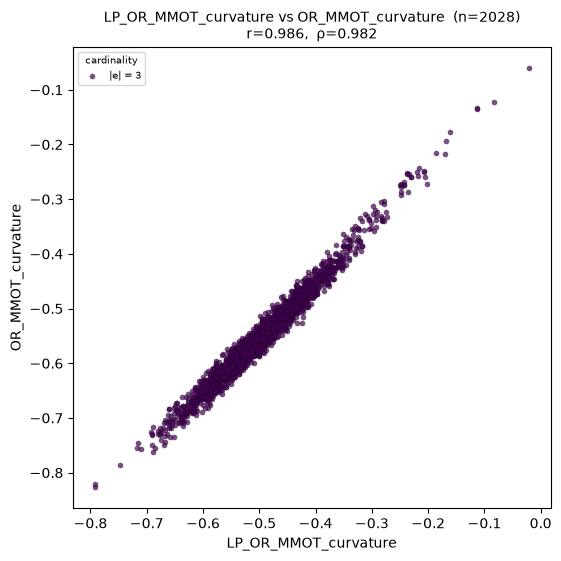

In [32]:

df, strat = analyse(FILE_A, FILE_B, drop_nan=DROP_NAN, min_group=MIN_GROUP)

In [33]:
diff = (df["value_a"] - df["value_b"]).to_numpy()

print(f"n      = {len(diff)}")
print(f"mean   = {diff.mean():.4f}")
print(f"median = {np.median(diff):.4f}")

n      = 2028
mean   = 0.0544
median = 0.0551
